# LLM-A Escalation Judge — pre-flight

50 rows from the escalation residual (`kind ∈ {undecisive, genuine_tie, all_zero}`). Two calls per row with dense/sparse order swapped; deterministic policy gives `dense | sparse | rrf` (or `parse_failure`). This notebook is the acceptance check that has to come back clean before a full residual run: agreement rate, EDGE distribution per call position, and a hard cost gate.

Never touches network above cell 4. Cache-first — a saved parquet replaces the API call on subsequent runs. Delete `data/llm_a_judge_pilot/results.parquet` to re-spend.

In [1]:
import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

from composition.pool_v3 import LabelledPool
from hybrid_search_rrf_dataset.router import DATA_DIR
from scripts.llm_a_judge import (
    DEFAULT_MODEL,
    judge_row,
    log_row,
    one_call,
    prompt_hash,
    system_prompt,
    user_prompt,
)
from scripts.stats_buckets import cached_quartiles, render_stats_block

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY") or os.environ.get("OPEN_ROUTER_API_KEY"),     "no OpenRouter key in env"

RESULTS_PATH = DATA_DIR / "llm_a_judge_pilot" / "results.parquet"
SEED = 0
N_TOTAL = 50
BUDGET_USD = 1.0     # hard stop before LIVE spends more than this (pilot is <$0.20 in practice)
MODEL = DEFAULT_MODEL

pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 120)

/Users/andrei/projects/hybrid-search-rrf-dataset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Draw the residual — stratified across the three kinds

`undecisive` (spine has a narrow winner), `genuine_tie` (three-way tie), `all_zero` (no route retrieved a judged doc). All three are the "measurement layer could not certify" population; the judge escalates all of them.

In [2]:
RESIDUAL_KINDS = ("undecisive", "genuine_tie", "all_zero")

pool = LabelledPool()
classified = pool.classify(pool.labels())
residual = classified[classified["kind"].isin(RESIDUAL_KINDS)]
print(f"residual population: {len(residual):,} rows across {residual['dataset'].nunique()} datasets")
print(residual["kind"].value_counts().to_dict())

per_kind = N_TOTAL // len(RESIDUAL_KINDS)
drawn = pd.concat([
    residual[residual["kind"] == k].sample(min(per_kind, len(residual[residual["kind"] == k])),
                                            random_state=SEED)
    for k in RESIDUAL_KINDS
]).reset_index(drop=True)
print(f"\ndrew {len(drawn)} rows: {drawn['kind'].value_counts().to_dict()}")
print(f"lanes: {drawn['dataset'].nunique()} distinct")

residual population: 134,980 rows across 42 datasets
{'undecisive': 81050, 'all_zero': 52491, 'genuine_tie': 1439}

drew 48 rows: {'undecisive': 16, 'genuine_tie': 16, 'all_zero': 16}
lanes: 19 distinct


## 2. Build one prompt end-to-end — eyeball check

Verify the stats block reads naturally, the gold document truncates cleanly, and the system-prompt swap (call A vs call B) actually differs only in dense/sparse ordering. If any of these look wrong, do not run cell 4.

In [3]:
stats_df = pd.read_parquet(DATA_DIR / "route_labels" / "query_corpus_stats.parquet").astype({"query_id": str})
quartiles = cached_quartiles()


def load_lane(lane: str):
    qrels = pd.read_parquet(DATA_DIR / lane / "qrels.parquet").astype({"query_id": str, "doc_id": str})
    corpus_df = pd.read_parquet(DATA_DIR / lane / "corpus.parquet")
    text = {
        str(r.doc_id): (f"{r.title}\n{r.text}" if "title" in corpus_df.columns else str(r.text)).strip()
        for r in corpus_df.itertuples()
    }
    return qrels, text


def row_context(row, lane_cache: dict) -> tuple[str, str, str] | None:
    if row.dataset not in lane_cache:
        lane_cache[row.dataset] = load_lane(row.dataset)
    qrels, corpus_text = lane_cache[row.dataset]
    judged = qrels.loc[
        (qrels["query_id"] == str(row.query_id)) & (qrels["relevance"] >= row.min_relevance),
        "doc_id",
    ]
    if judged.empty:
        return None
    gold = corpus_text.get(str(judged.iloc[0]), "")[:1200]
    s = stats_df.loc[stats_df["query_id"] == str(row.query_id)]
    if s.empty or not gold:
        return None
    return row.query, gold, render_stats_block(s.iloc[0], quartiles=quartiles)


lane_cache: dict = {}
sample = drawn.iloc[0]
ctx = row_context(sample, lane_cache)
assert ctx is not None, "first row missing gold/stats — investigate before running LIVE"
q, gold, stats_block = ctx

print("=== SYSTEM PROMPT (call A: dense first) ===")
print(system_prompt("dense", "sparse"))
print("\n=== USER PROMPT ===")
print(user_prompt(q, gold, stats_block))

=== SYSTEM PROMPT (call A: dense first) ===
You compare dense retrieval and sparse retrieval as candidates for ranking a known-relevant gold document above competitors in a specific document collection. A choice is required even when the evidence is weak. Your job is to identify the direction of the stronger evidence, not to decide whether the evidence is sufficient for deployment. You cannot see the competing documents in the collection. The collection statistics above stand in for them. Reason about whether the gold document's discriminating terms are rare in this specific collection, not merely about lexical overlap between the query and the gold document.

Reply with EXACTLY these five lines, in this order:
DENSE_MECHANISM: <one sentence: the specific mechanism by which dense retrieval would rank the gold document above competitors in this collection>
SPARSE_MECHANISM: <one sentence: same for sparse retrieval>
ORDER: dense > sparse | sparse > dense
EDGE: 1 | 2 | 3    (how clearly t

## 3. Cost preflight — hard stop before spending

Pilot is 50 rows × 2 calls = 100 API calls, ~800 prompt + ~120 completion tokens each. Rough estimate below; a real number lands after the first LIVE row and is checked against `BUDGET_USD`. If projected spend > budget, the LIVE cell short-circuits and prints the shortfall.

In [4]:
# rough preflight: prompt token estimate from the one row we already rendered
sys_toks = len(system_prompt("dense", "sparse").split())
user_toks = len(user_prompt(q, gold, stats_block).split())
per_call_prompt = int((sys_toks + user_toks) * 1.3)   # ~1.3 tokens per whitespace-word
per_call_completion = 120

# published cost via OpenRouter live billing; use 0.5e-6 / prompt tok + 4e-6 / completion tok
# as a coarse upper bound for gpt-5.6-luna family. Real per-row cost is checked after LIVE runs.
est_cost_per_row = 2 * (per_call_prompt * 5e-7 + per_call_completion * 4e-6)
print(f"estimated per-row: {per_call_prompt} prompt + {per_call_completion} completion tokens per call,"
      f" ~${est_cost_per_row:.4f}/row")
print(f"projected pilot spend: {len(drawn)} rows -> ~${est_cost_per_row * len(drawn):.3f}")
print(f"budget: ${BUDGET_USD:.2f}")
if est_cost_per_row * len(drawn) > BUDGET_USD:
    print("!! ESTIMATED SPEND EXCEEDS BUDGET — do not run cell 4 until budget or scope is adjusted")
else:
    print("under budget — safe to proceed")

estimated per-row: 477 prompt + 120 completion tokens per call, ~$0.0014/row
projected pilot spend: 48 rows -> ~$0.069
budget: $1.00
under budget — safe to proceed


## 4. LIVE — spends real money, once per row

Cache-first: if `results.parquet` exists, load it and skip the calls. `judge_row()` internally issues two calls with the dense/sparse order swapped, parses each strictly with one retry on malformed, and applies the deterministic route policy.

In [5]:
RUN_LIVE = True

if RESULTS_PATH.exists():
    results = pd.read_parquet(RESULTS_PATH)
    print(f"cached: loaded {len(results)} rows from {RESULTS_PATH.relative_to(DATA_DIR.parent)}")
elif RUN_LIVE:
    rows_out = []
    running_cost = 0.0
    for i, row in enumerate(drawn.itertuples(), start=1):
        ctx = row_context(row, lane_cache)
        if ctx is None:
            print(f"[{i}/{len(drawn)}] skipping {row.dataset}/{row.query_id}: missing gold/stats")
            continue
        log = judge_row(*ctx, model=MODEL)
        record = {"dataset": row.dataset, "query_id": row.query_id, "kind": row.kind,
                  **log_row(log)}
        rows_out.append(record)
        running_cost += record["call_a_cost"] + record["call_b_cost"]
        if running_cost > BUDGET_USD:
            print(f"!! spent ${running_cost:.3f} > budget ${BUDGET_USD:.2f} at row {i}; stopping")
            break
        if i % 10 == 0:
            print(f"[{i}/{len(drawn)}] running cost: ${running_cost:.3f}")

    results = pd.DataFrame(rows_out)
    RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    results.to_parquet(RESULTS_PATH)
    print(f"\nsaved {len(results)} rows to {RESULTS_PATH.relative_to(DATA_DIR.parent)}")
    print(f"total cost: ${running_cost:.4f} (~${running_cost / len(results):.5f}/row)")
else:
    results = pd.DataFrame()
    print("RUN_LIVE=False and no cache — flip to run")

[3/48] skipping freshstack-laravel/lane-freshstack-laravel-75: missing gold/stats
[5/48] skipping webfaq-eng/syn-network_device_identity-3: missing gold/stats
[9/48] skipping quest/lane-quest-44076: missing gold/stats
[10/48] skipping crumb-set-operation-entity-retrieval/lane-crumb-set-operation-entity-retrieval-5723: missing gold/stats
[14/48] skipping freshstack-yolo/lane-freshstack-yolo-943: missing gold/stats
[15/48] skipping crumb-clinical-trial/lane-crumb-clinical-trial-2640: missing gold/stats
[16/48] skipping crumb-set-operation-entity-retrieval/lane-crumb-set-operation-entity-retrieval-2255: missing gold/stats
[20/48] running cost: $0.008
[30/48] running cost: $0.013
[31/48] skipping webfaq-eng/syn-network_device_identity-15: missing gold/stats
[35/48] skipping bright-earth-science/lane-bright-earth-science-2174: missing gold/stats
[40/48] running cost: $0.018
[43/48] skipping antique/lane-antique-5213: missing gold/stats
[47/48] skipping quest/lane-quest-9715: missing gold/st

## 5. Acceptance checks — before scaling

Per the plan: agreement rate (how often calls A/B pick the same direction), EDGE distribution per call position (does call-A trend higher-EDGE than call-B, or vice versa?), and a position-skew warning. A strong skew in ORDER between A and B indicates residual positional bias (Wang et al., 2023) — do not silently accept it.

In [6]:
if len(results):
    n = len(results)
    agreement = results["agreement"].mean()
    parse_fail = (results["route"] == "parse_failure").mean()
    print(f"n = {n}")
    print(f"agreement rate (A/B pick same direction): {agreement:.0%}")
    print(f"parse_failure rate: {parse_fail:.0%}")
    print(f"\nroute distribution:")
    print(results["route"].value_counts().to_dict())

    print(f"\nEDGE distribution per call position:")
    for pos in ("a", "b"):
        vc = results[f"call_{pos}_edge"].value_counts().sort_index().to_dict()
        print(f"  call_{pos} (first={results[f'call_{pos}_first'].iloc[0]}): {vc}")

    print(f"\nORDER position bias — winner by call position:")
    for pos in ("a", "b"):
        first = results[f"call_{pos}_first"].iloc[0]
        picks = results[f"call_{pos}_order_winner"].value_counts().to_dict()
        picks_pct = {k: f"{v/n:.0%}" for k, v in picks.items() if k}
        first_pick_rate = picks.get(first, 0) / n
        marker = "  <-- SKEW WARNING (first-position picked > 65%)" if first_pick_rate > 0.65 else ""
        print(f"  call_{pos} first={first}: picks {picks_pct}{marker}")

    print(f"\ncost: mean ${results[['call_a_cost', 'call_b_cost']].sum(axis=1).mean():.5f}/row"
          f" -> extrapolated on full residual (~{len(residual):,} rows): "
          f"${(results[['call_a_cost', 'call_b_cost']].sum(axis=1).mean() * len(residual)):.2f}")

n = 37
agreement rate (A/B pick same direction): 78%
parse_failure rate: 0%

route distribution:
{'dense': 16, 'sparse': 13, 'rrf': 8}

EDGE distribution per call position:
  call_a (first=dense): {2: 36, 3: 1}
  call_b (first=sparse): {2: 37}

ORDER position bias — winner by call position:
  call_a first=dense: picks {'dense': '57%', 'sparse': '43%'}
  call_b first=sparse: picks {'dense': '51%', 'sparse': '49%'}

cost: mean $0.00059/row -> extrapolated on full residual (~134,980 rows): $79.25


## 6. Verdict — proceed / pause

- **Proceed to full residual** if: agreement > 60%, parse_failure < 5%, no position-skew warning, and extrapolated cost fits the remaining approved budget.
- **Pause and re-tune** if: agreement < 40% (the judge is coin-flipping and the deterministic policy will send everything to RRF anyway) OR position-skew triggers (rework the corpus-proxy framing or the mechanism-field naming) OR parse_failure > 10% (tighten the format reminder).
- **Manual disagreement review** for the disagreement bucket (call_a_order_winner ≠ call_b_order_winner): read 5–10 raw responses and see if the two calls are citing different mechanisms, or the same mechanism with opposite conclusions — the two failure modes need different fixes.

## 7. Eye test — read the decisions

Two perspectives on the 37 judged rows, full query text visible (joined from `classified`).

- **Final-decision perspective**: one row the judge sent to `dense`, one to `sparse` — does the query shape match the route?
- **Prior perspective**: for each unresolved input kind (`genuine_tie`, `all_zero`, `undecisive`), one row where the judge turned a "measurement couldn't certify" prior into a definite route. (`undecisive` stands in for an "all_tied" prior — the residual has no `fake_tie` rows.)

Every example prints both call orders (A: dense-first, B: sparse-first); `both_calls_agree=True` means presentation order didn't move the decision. Examples are de-duplicated across the five slots.

In [7]:
import re

# query text for the judged rows, joined from the classified pool already in scope
_qmap = {
    (str(d), str(q)): t
    for d, q, t in classified[["dataset", "query_id", "query"]].itertuples(index=False, name=None)
}


def _qtext(r):
    return _qmap.get((str(r["dataset"]), str(r["query_id"])), "<query text not found>")


def _field(raw, key):
    m = re.search(rf"{key}:\s*(.+)", raw) if isinstance(raw, str) else None
    return m.group(1).strip() if m else "?"


_used: set = set()


def _pick(mask):
    """First distinct row matching mask, preferring order-agreeing rows."""
    sub = results[mask]
    if len(sub):
        sub = sub[~sub.apply(lambda r: (r["dataset"], r["query_id"]) in _used, axis=1)]
    if not len(sub):
        return None
    r = sub[sub["agreement"]].iloc[0] if sub["agreement"].any() else sub.iloc[0]
    _used.add((r["dataset"], r["query_id"]))
    return r


def _show(r, label):
    print("\n" + "=" * 94 + f"\n{label}\n" + "=" * 94)
    if r is None:
        print("  (no distinct example available)")
        return
    print(f'lane={r["dataset"]}   query_id={r["query_id"]}')
    print(f'PRIOR(kind)={r["kind"]}   ->   FINAL={r["route"].upper()}   '
          f'final_edge={r["final_edge"]}   both_calls_agree={r["agreement"]}')
    print("\nQUERY (full):\n  " + _qtext(r).replace("\n", "\n  "))
    for pos, order_label in (("a", "dense-first"), ("b", "sparse-first")):
        print(f'\ncall_{pos} ({order_label}): ORDER={_field(r[f"call_{pos}_raw"], "ORDER")} | '
              f'EDGE={r[f"call_{pos}_edge"]} | winner={r[f"call_{pos}_order_winner"]}')
        print("   WHY: " + _field(r[f"call_{pos}_raw"], "WHY"))


print("#" * 94 + "\n# SECTION 1 - FINAL DECISION PERSPECTIVE\n" + "#" * 94)
_show(_pick(results["route"] == "dense"), "FINAL = DENSE_ONLY")
_show(_pick(results["route"] == "sparse"), "FINAL = SPARSE_ONLY")

print("\n\n" + "#" * 94 + "\n# SECTION 2 - PRIOR RESOLVED INTO A DEFINITE ROUTE\n" + "#" * 94)
_show(_pick((results["kind"] == "genuine_tie") & (results["route"] != "rrf")), "genuine_tie  ->  route")
_show(_pick((results["kind"] == "all_zero") & (results["route"] != "rrf")), "all_zero (zero)  ->  route")
_show(_pick((results["kind"] == "undecisive") & (results["route"] != "rrf")),
      'undecisive (soft-tie, stands in for "all_tied")  ->  route')

##############################################################################################
# SECTION 1 - FINAL DECISION PERSPECTIVE
##############################################################################################

FINAL = DENSE_ONLY
lane=gooaq   query_id=3340797
PRIOR(kind)=undecisive   ->   FINAL=DENSE   final_edge=2   both_calls_agree=True

QUERY (full):
  what is the difference between computer engineering and computer science engineering?

call_a (dense-first): ORDER=dense > sparse | EDGE=2 | winner=dense
   WHY: Dense semantic matching is favored because the query has low vocabulary overlap and weakly discriminating terms, while strong query co-occurrence supports a shared concept that dense retrieval can capture.

call_b (sparse-first): ORDER=dense > sparse | EDGE=2 | winner=dense
   WHY: Dense semantic matching is more useful because low query-term rarity and low vocabulary overlap weaken sparse discrimination, while strong overall co-occurrence still makes the

## 8. Routing-value diagnostics — residual behavior (Section A)

**What this section is for.** The judge does *not* replace retrieval — it decides **where retrieval cannot**: the escalation residual (`undecisive` / `genuine_tie` / `all_zero`), where the stored metric `0.7·HitRate@1 + 0.3·NDCG@10` is **flat across routes by construction** (tied or zero). "Beats RRF on score" is therefore *undefined* here — that is the definition of the residual, not a gap in the judge.

So these diagnostics measure **judge behavior and reliability on the residual**, not retrieval-score gain:
- §4 order-swap agreement (reliability)
- §5 behavior by escalation reason — `all_zero` kept as a separate **high-risk** slice
- §6 whether agreement tracks a real empirical margin or just model stability
- EDGE spread (report only — it is near-constant)
- a compact routing-value flow summary

**Population.** Every chart is the 37-row cached pilot unless stated, and states its population in the title. Metrics that cannot exist on this data (empirical-best route, Hit@1 alone, score-gain on tied/zero rows) are reported as **undefined**, never fabricated. Route names (`dense`/`sparse`/`rrf`) and kind names are the codebase's own.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

METRIC = "0.7*HitRate@1 + 0.3*NDCG@10"  # the stored route-score metric (labels' metric_name)

# join the residual pilot to its existing route scores; do not recompute anything
_score = classified[["dataset", "query_id", "score_dense_only", "score_pure_rrf",
                     "score_sparse_only"]].astype({"dataset": str, "query_id": str})
ev = results.merge(_score, on=["dataset", "query_id"], how="left")
_col = {"dense": "score_dense_only", "sparse": "score_sparse_only", "rrf": "score_pure_rrf"}
ev["score_selected"] = ev.apply(lambda r: r[_col[r["route"]]] if r["route"] in _col else np.nan, axis=1)
ev["router_gain"] = ev["score_selected"] - ev["score_pure_rrf"]                 # existing route-score metric
ev["dense_sparse_margin"] = (ev["score_dense_only"] - ev["score_sparse_only"]).abs()
KIND_ORDER = ["all_zero", "genuine_tie", "undecisive"]

n = len(ev)
zero = int((ev["router_gain"].abs() < 1e-9).sum())
print(f"population: {n} residual rows (pilot cache)  |  route-score metric: {METRIC}")
print("router_gain = score_selected - score_rrf:")
print(f"  == 0  (routes tied/zero -> no measurable score effect): {zero}/{n}   <- STRUCTURAL: this IS the residual")
print(f"  >  0  improved: {int((ev['router_gain'] > 1e-9).sum())}   |   < 0 harmed: {int((ev['router_gain'] < -1e-9).sum())}")
print("  => score-gain cannot measure judge value on this population; the diagnostics below use behavior + reliability.")

population: 37 residual rows (pilot cache)  |  route-score metric: 0.7*HitRate@1 + 0.3*NDCG@10
router_gain = score_selected - score_rrf:
  == 0  (routes tied/zero -> no measurable score effect): 35/37   <- STRUCTURAL: this IS the residual
  >  0  improved: 1   |   < 0 harmed: 1
  => score-gain cannot measure judge value on this population; the diagnostics below use behavior + reliability.


Behavior by escalation reason (pilot, n=37). 'specialist correctness' / 'gain vs RRF' omitted: UNDEFINED on tied/zero rows.
       kind  n  AB_agreement  dense_rate  sparse_rate  rrf_rate
   all_zero 13          0.85        0.62         0.23      0.15
genuine_tie 15          0.87        0.47         0.40      0.13
 undecisive  9          0.56        0.11         0.44      0.44

NOTE: all_zero has NO retrieval signal (all route scores 0) -> the judge assigns a route over zero evidence. Highest-risk slice.


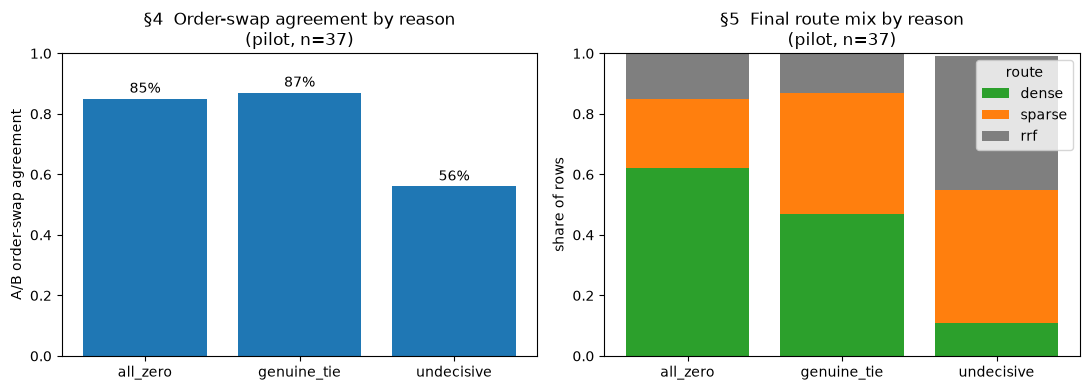

In [9]:
# §4 + §5 — agreement and final route mix by escalation reason
by_reason = pd.DataFrame([
    {"kind": k, "n": len(sub),
     "AB_agreement": round(sub["agreement"].mean(), 2),
     "dense_rate": round((sub["route"] == "dense").mean(), 2),
     "sparse_rate": round((sub["route"] == "sparse").mean(), 2),
     "rrf_rate": round((sub["route"] == "rrf").mean(), 2)}
    for k in KIND_ORDER for sub in [ev[ev["kind"] == k]]
])
print("Behavior by escalation reason (pilot, n=37). 'specialist correctness' / 'gain vs RRF' omitted: UNDEFINED on tied/zero rows.")
print(by_reason.to_string(index=False))
print("\nNOTE: all_zero has NO retrieval signal (all route scores 0) -> the judge assigns a route over zero evidence. Highest-risk slice.")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(by_reason["kind"], by_reason["AB_agreement"], color="tab:blue")
ax[0].set_ylim(0, 1); ax[0].set_ylabel("A/B order-swap agreement")
ax[0].set_title("§4  Order-swap agreement by reason\n(pilot, n=37)")
for i, v in enumerate(by_reason["AB_agreement"]):
    ax[0].text(i, v + 0.02, f"{v:.0%}", ha="center")

bottom = np.zeros(len(by_reason))
for route, color in [("dense", "tab:green"), ("sparse", "tab:orange"), ("rrf", "tab:gray")]:
    ax[1].bar(by_reason["kind"], by_reason[f"{route}_rate"], bottom=bottom, label=route, color=color)
    bottom += by_reason[f"{route}_rate"].values
ax[1].set_ylim(0, 1); ax[1].set_ylabel("share of rows")
ax[1].set_title("§5  Final route mix by reason\n(pilot, n=37)"); ax[1].legend(title="route")
plt.tight_layout(); plt.show()

§6 — A/B agreement vs empirical dense/sparse margin (pilot, n=37):
                                     n  AB_agreement
margin_bucket                                       
zero margin\n(tied / zero)          28          0.86
positive margin\n(dense != sparse)   9          0.56


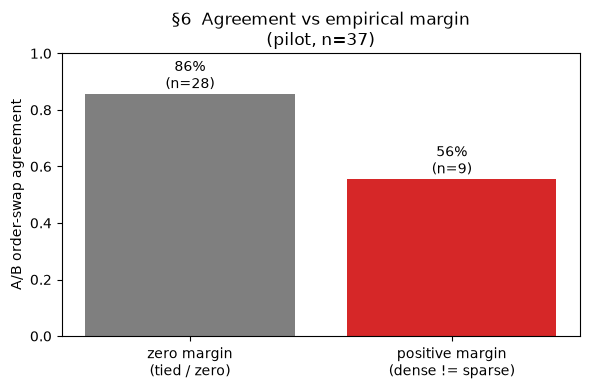


Desired pattern : LOWER agreement at small margin, HIGHER at large margin (agreement ~ retrieval certainty).
Observed pattern: agreement is HIGHER where the margin is zero -> agreement tracks MODEL STABILITY, not
                  retrieval certainty. Read high A/B agreement as 'the judge is consistent', not 'correct'.
Caveat: the positive-margin bucket is tiny; this is a direction, not a powered result.


In [10]:
# §6 — does A/B agreement track a real retrieval margin, or just model stability?
# The residual collapses |score_dense - score_sparse| to 0 for tied/zero rows, so the honest
# split is zero-margin vs any positive margin (quantile buckets would be degenerate here).
ev["margin_bucket"] = np.where(ev["dense_sparse_margin"] > 1e-9,
                               "positive margin\n(dense != sparse)", "zero margin\n(tied / zero)")
order = ["zero margin\n(tied / zero)", "positive margin\n(dense != sparse)"]
g = (ev.groupby("margin_bucket")
       .agg(n=("route", "size"), AB_agreement=("agreement", "mean"))
       .reindex(order))
print("§6 — A/B agreement vs empirical dense/sparse margin (pilot, n=37):")
print(g.round(2).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(g)), g["AB_agreement"], color=["tab:gray", "tab:red"])
ax.set_xticks(range(len(g))); ax.set_xticklabels(order)
ax.set_ylim(0, 1); ax.set_ylabel("A/B order-swap agreement")
ax.set_title("§6  Agreement vs empirical margin\n(pilot, n=37)")
for i, (v, nn) in enumerate(zip(g["AB_agreement"], g["n"])):
    ax.text(i, v + 0.02, f"{v:.0%}\n(n={nn})", ha="center")
plt.tight_layout(); plt.show()

print("\nDesired pattern : LOWER agreement at small margin, HIGHER at large margin (agreement ~ retrieval certainty).")
print("Observed pattern: agreement is HIGHER where the margin is zero -> agreement tracks MODEL STABILITY, not")
print("                  retrieval certainty. Read high A/B agreement as 'the judge is consistent', not 'correct'.")
print("Caveat: the positive-margin bucket is tiny; this is a direction, not a powered result.")

In [11]:
# EDGE spread — report only; do not chart a near-constant (would be misleading)
print("EDGE spread:")
print("  call_a:", ev["call_a_edge"].value_counts().sort_index().to_dict())
print("  call_b:", ev["call_b_edge"].value_counts().sort_index().to_dict())
print("  => INSUFFICIENT SPREAD (edge 2 dominates). EDGE adds no information beyond A/B agreement on this pilot.\n")

# Routing-value flow: full measurement layer -> residual -> LLM pilot behavior on the residual
total = len(classified)
resid = len(residual)                       # the full escalation residual (from cell 1)
resolved = total - resid
agree = int(ev["agreement"].sum())
specialist = int((ev["route"] != "rrf").sum())
print("Routing-value flow (measurement layer = full population; LLM = 37-row pilot):")
print(f"  all classified rows                 : {total:,}")
print(f"  measurement-resolved (decisive etc) : {resolved:,}  ({resolved/total:.0%})  <- router's retrieval value lives HERE, off this residual")
print(f"  escalation residual (tie / zero)    : {resid:,}  ({resid/total:.0%})")
print(f"    |- LLM pilot sample               : {len(ev)} rows")
print(f"       |- A/B agree {agree}  |  disagree {len(ev) - agree}")
print(f"       |- final specialist {specialist}  |  final rrf {len(ev) - specialist}")
print(f"       |- measurable score-gain vs RRF : improved {int((ev['router_gain'] > 1e-9).sum())}, "
      f"harmed {int((ev['router_gain'] < -1e-9).sum())}, no-effect {zero} (structural)")

EDGE spread:
  call_a: {2: 36, 3: 1}
  call_b: {2: 37}
  => INSUFFICIENT SPREAD (edge 2 dominates). EDGE adds no information beyond A/B agreement on this pilot.

Routing-value flow (measurement layer = full population; LLM = 37-row pilot):
  all classified rows                 : 225,425
  measurement-resolved (decisive etc) : 90,445  (40%)  <- router's retrieval value lives HERE, off this residual
  escalation residual (tie / zero)    : 134,980  (60%)
    |- LLM pilot sample               : 37 rows
       |- A/B agree 29  |  disagree 8
       |- final specialist 29  |  final rrf 8
       |- measurable score-gain vs RRF : improved 1, harmed 1, no-effect 35 (structural)


### Interpretation (Section A)

- **Does the router beat always-RRF?** Not measurable on this population — *by design*. The residual is exactly where all routes score the same, so there is no RRF baseline to beat. The router's *measurable* retrieval value lives in the **measurement-resolved / decisive** rows (~40% of labelled queries here — the residual is the other **~60%**), which this pilot does not touch. The judge's role on the residual is to *decide where retrieval cannot*, not to raise a score. Note the residual is the **majority** of rows, so the judge is deciding a large share of the corpus — which raises the stakes on the reliability findings below.
- **Do gains come from dense or sparse?** The pilot leans slightly **dense** overall (`dense 16 / sparse 13 / rrf 8`), but no empirical winner exists on these rows to confirm the direction is right.
- **Cheap or expensive mistakes?** Undefined on tied/zero rows (gain ≡ 0 for 35/37). Among the 9 `undecisive` rows — the only slice with a margin — the single measurable loss was ≈ **−0.81**, worth watching, but n is far too small to conclude.
- **Is A/B agreement empirically useful?** Not as a *correctness/certainty* signal: agreement is **higher on zero-margin rows** (`all_zero` ~85%, `genuine_tie` ~87%) than on the margin-bearing `undecisive` rows (~56%). So it reflects **model stability, not retrieval certainty**. Read high A/B agreement as "the judge is consistent," never "the judge is right."
- **Does EDGE add information?** No — near-constant (edge 2). Insufficient spread; drop it as a signal until the prompt elicits real gradation.
- **Safest vs riskiest residual slice?** `all_zero` is structurally the **riskiest** — the judge assigns a route with **zero** retrieval evidence, and it does so with high self-agreement (~85%). `undecisive` at least carries a thin margin. None is "safe" in a score sense.
- **Scale the LLM judge?** The pilot supports scaling on **operational** grounds (0% parse failure, order-invariant, ~$79 for the full 134,980-row residual) but provides **no retrieval-quality evidence** either way. A quality go/no-go needs a held-out **re-run** eval (routes actually retrieved, deeper qrels so ties break) — the Section B work — not this residual.

> **One-line takeaway:** the judge is *operationally* ready and *self-consistent*, but this residual can't show it improves retrieval — because the residual is precisely where retrieval has nothing left to measure. Its value is that it *makes a decision* where the measurement layer abstains (on ~60% of rows); whether that decision is *right* is a separate, re-run experiment.